In [ ]:
!pip install -q python-dotenv transformers datasets scikit-learn torch gensim sentencepiece

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/NLP'
if PROJECT_PATH not in sys.path:
    sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)

from data.data_processor import DataProcessor
from features.tfidf import TFIDF
from models.svm_classifier import FinalSVMClassifier
from evaluation.post_processor import ModelPostProcessor

load_dotenv(os.path.join(PROJECT_PATH, '.env'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 26.0 MB/s eta 0:00:00
Mounted at /content/drive


False

In [ ]:
processor = DataProcessor()
data = processor.process_data(
    train_path='csv/train.csv',
    val_path='csv/valid.csv',
    test_path='csv/test.csv',
    tokenize=False
)

train_df = data['train_df']
val_df   = data['val_df']
test_df  = data['test_df']

print(f"Δείγματα Εκπαίδευσης: {len(train_df)}")
print(f"Δείγματα Επικύρωσης: {len(val_df)}")
print(f"Δείγματα Δοκιμής: {len(test_df)}")

Δείγματα Εκπαίδευσης: 5082
Δείγματα Επικύρωσης: 565
Δείγματα Δοκιμής: 997


In [ ]:
#SVM + TF-IDF (C+5.0)
tfidf = TFIDF(max_features=15000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df['clean_text'])
X_val_tfidf   = tfidf.transform(val_df['clean_text'])
X_test_tfidf  = tfidf.transform(test_df['clean_text'])

#HAZARD
svm_haz = FinalSVMClassifier(C=5.0)
svm_haz.train(X_train_tfidf, train_df['hazard_label'])
svm_haz_val_probs = svm_haz.predict_proba(X_val_tfidf)
svm_haz_test_probs = svm_haz.predict_proba(X_test_tfidf)

#PRODUCT
svm_prod = FinalSVMClassifier(C=5.0)
svm_prod.train(X_train_tfidf, train_df['product_label'])
svm_prod_val_probs = svm_prod.predict_proba(X_val_tfidf)
svm_prod_test_probs = svm_prod.predict_proba(X_test_tfidf)


In [ ]:
PROBS_DIR = 'models/probs'

#BERT
bert_haz_val_probs   = np.load(f'{PROBS_DIR}/bert_haz_val_probs.npy')
bert_haz_test_probs  = np.load(f'{PROBS_DIR}/bert_haz_test_probs.npy')
bert_prod_val_probs  = np.load(f'{PROBS_DIR}/bert_prod_val_probs.npy')
bert_prod_test_probs = np.load(f'{PROBS_DIR}/bert_prod_test_probs.npy')

#RoBERTa
rob_haz_val_probs    = np.load(f'{PROBS_DIR}/roberta_haz_val_probs.npy')
rob_haz_test_probs   = np.load(f'{PROBS_DIR}/roberta_haz_test_probs.npy')
rob_prod_val_probs   = np.load(f'{PROBS_DIR}/roberta_prod_val_probs.npy')
rob_prod_test_probs  = np.load(f'{PROBS_DIR}/roberta_prod_test_probs.npy')

In [ ]:
W_BERT = 0.35
W_ROB  = 0.35
W_SVM  = 0.30

#Validation Set Ensemble
ens_haz_val_probs = (W_BERT * bert_haz_val_probs) + (W_ROB * rob_haz_val_probs) + (W_SVM * svm_haz_val_probs)
ens_prod_val_probs = (W_BERT * bert_prod_val_probs) + (W_ROB * rob_prod_val_probs) + (W_SVM * svm_prod_val_probs)

ens_haz_val_preds = np.argmax(ens_haz_val_probs, axis=-1)
ens_prod_val_preds = np.argmax(ens_prod_val_probs, axis=-1)

#Ensemble
ens_haz_test_probs = (W_BERT * bert_haz_test_probs) + (W_ROB * rob_haz_test_probs) + (W_SVM * svm_haz_test_probs)
ens_prod_test_probs = (W_BERT * bert_prod_test_probs) + (W_ROB * rob_prod_test_probs) + (W_SVM * svm_prod_test_probs)

ens_haz_test_preds = np.argmax(ens_haz_test_probs, axis=-1)
ens_prod_test_preds = np.argmax(ens_prod_test_probs, axis=-1)


In [ ]:
post_processor_ens = ModelPostProcessor(
    model_prefix="multimodal_ensemble",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    data_dict=data
)

post_processor_ens.evaluate_and_export(
    preds_haz_val=ens_haz_val_preds,
    preds_prod_val=ens_prod_val_preds,
    preds_haz_test=ens_haz_test_preds,
    preds_prod_test=ens_prod_test_preds
)

ST1 SCORE (Validation): 0.7798
Hazard F1: 0.8839 | Product F1: 0.6757
Το αρχείο 'csv/multimodal_ensemble_submission.csv' δημιουργήθηκε επιτυχώς (997 γραμμές).


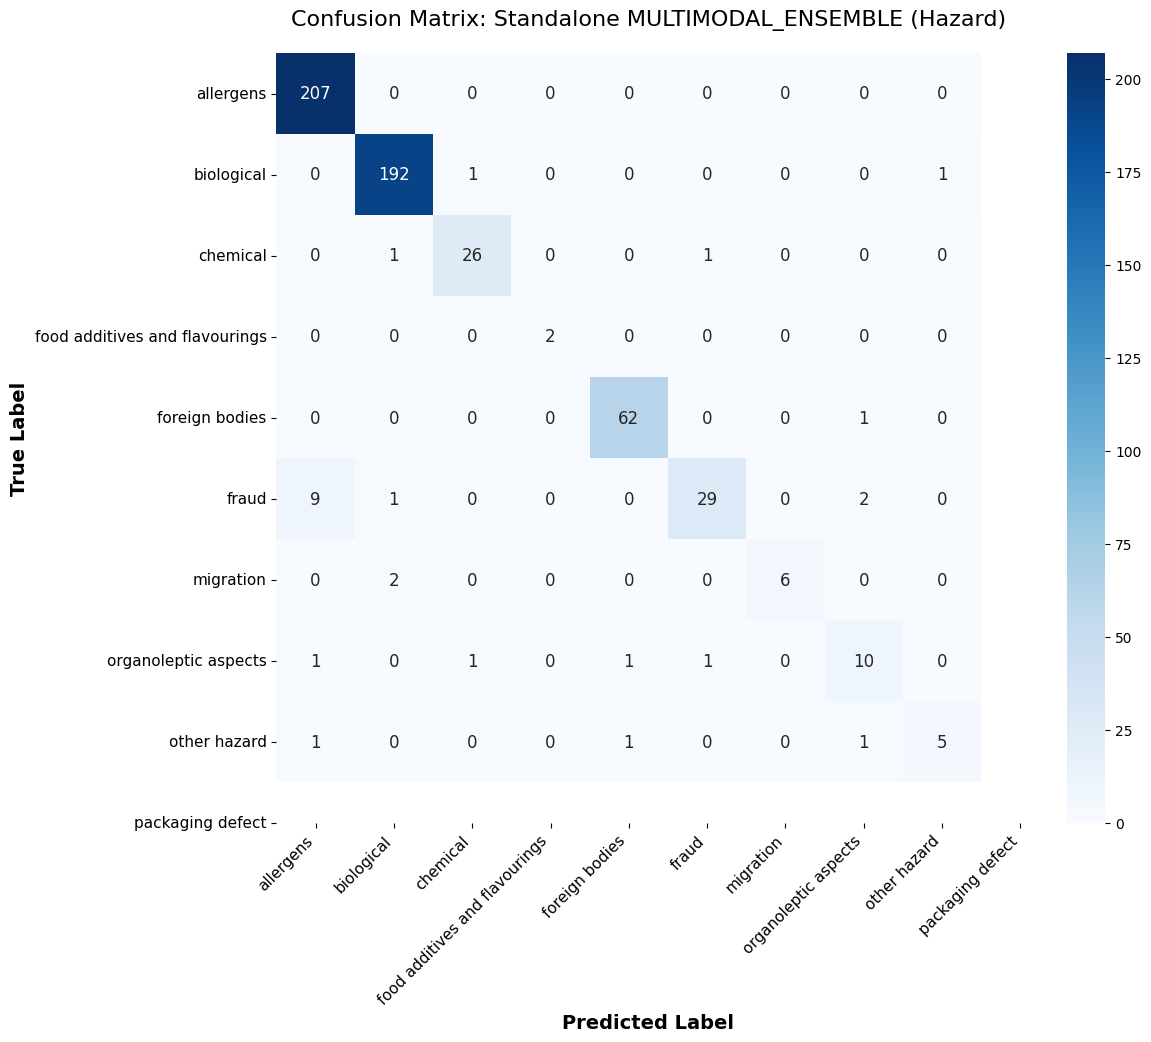

In [ ]:
post_processor_ens.plot_hazard_confusion_matrix(preds_haz_val=ens_haz_val_preds)

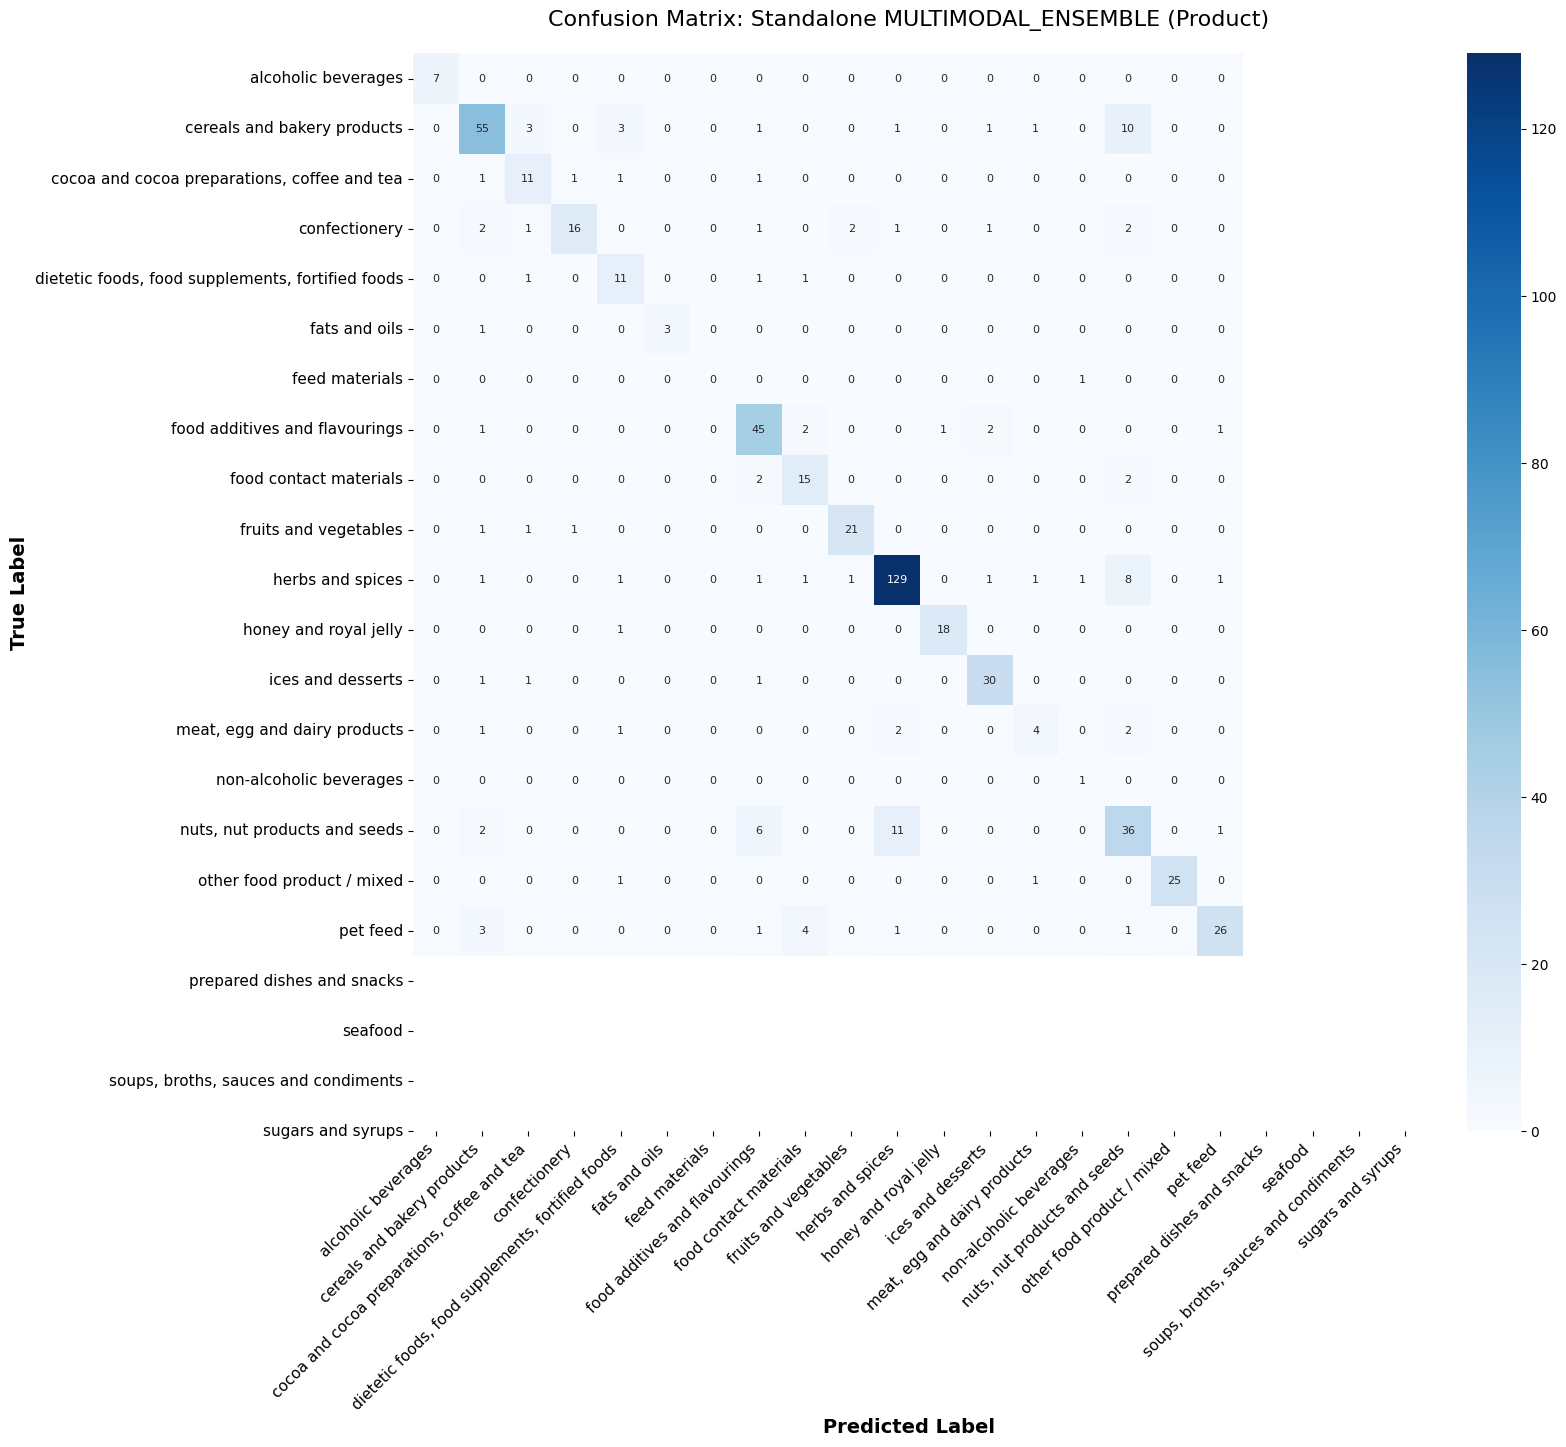

In [ ]:
post_processor_ens.plot_product_confusion_matrix(preds_prod_val=ens_prod_val_preds)

/tmp/ipykernel_1545/3977945915.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=models, y=scores, palette="viridis")


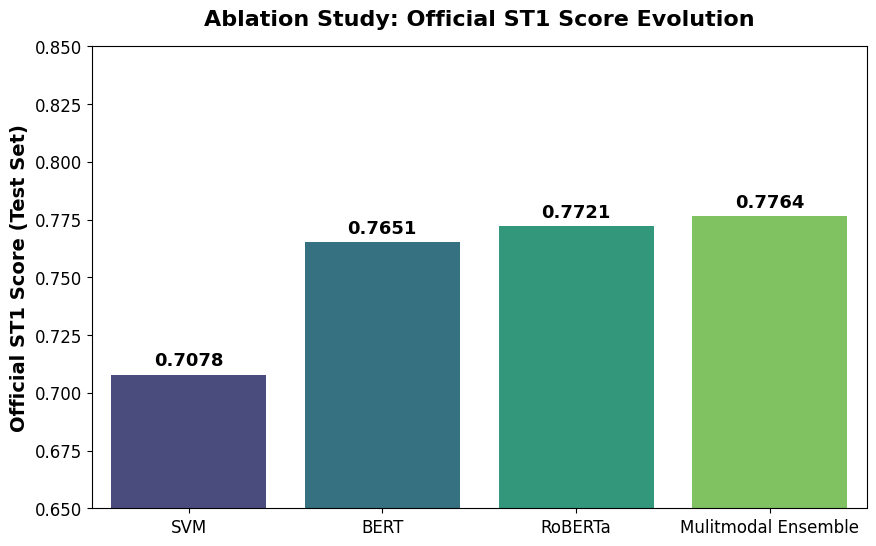

In [ ]:
models = ['SVM', 'BERT', 'RoBERTa', 'Mulitmodal Ensemble']
scores = [0.7078, 0.7651, 0.7721, 0.7764]

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=models, y=scores, palette="viridis")

plt.ylim(0.65, 0.85)
plt.title("Ablation Study: Official ST1 Score Evolution", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Official ST1 Score (Test Set)", fontsize=14, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                fontsize=13, fontweight='bold', color='black',
                xytext=(0, 10), textcoords='offset points')

img_dir = "images"
os.makedirs(img_dir, exist_ok=True)
filepath = os.path.join(img_dir, "ablation_study_st1.png")
plt.savefig(filepath, bbox_inches='tight', dpi=300)
plt.show()